# Selección del Clasificador Emocional — Comparativa de Modelos

**TFG — Chatbot de apoyo emocional para ciberacoso adolescente (UMU)**

Compara los resultados de fine-tuning de tres arquitecturas sobre EmoEvent con y sin class weights:
- **robertuito** — `pysentimiento/robertuito-base-uncased` (RoBERTa preentrenado en Twitter español)
- **maria-copy** — `PeterPanecillo/PlanTL-GOB-ES-roberta-base-bne-copy` (RoBERTa en corpus español general)
- **beto** — `dccuchile/bert-base-spanish-wwm-cased` (BERT en corpus español general)

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
EVAL_ROOT   = PROJECT_ROOT / 'eval' / 'emotion_results'
MODELS_ROOT = PROJECT_ROOT / 'models' / 'emotion_classifier'
DATA_DIR    = PROJECT_ROOT / 'data' / 'processed' / 'no_synthetic'

EMOTIONS = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'others']
CRITICAL = ['fear', 'sadness', 'anger', 'disgust']   # clases críticas para ciberacoso

# Carpetas disponibles en eval/emotion_results/
RESULT_DIRS = sorted([d for d in EVAL_ROOT.iterdir() if d.is_dir() and (d / 'test_metrics.json').exists()])
print('Carpetas de resultados encontradas:')
for d in RESULT_DIRS:
    print(f'  {d.name}')

Carpetas de resultados encontradas:
  beto
  beto_no_weights
  maria-copy
  maria-copy_no_weights
  robertuito
  robertuito_no_weights


In [2]:
# --- Carga de todos los test_metrics.json ---
def load_metrics(result_dir: Path) -> dict:
    with open(result_dir / 'test_metrics.json', encoding='utf-8') as f:
        m = json.load(f)
    name = result_dir.name
    has_weights = not name.endswith('_no_weights')
    base_name = name.replace('_no_weights', '')
    return {
        'carpeta': name,
        'modelo': base_name,
        'class_weights': 'Sí' if has_weights else 'No',
        'accuracy': m['accuracy'],
        'f1_macro': m['f1_macro'],
        **{f'f1_{e}': m['f1_per_class'].get(e, 0.0) for e in EMOTIONS},
    }

rows = [load_metrics(d) for d in RESULT_DIRS]
df_all = pd.DataFrame(rows)
print(f'Total de configuraciones cargadas: {len(df_all)}')

Total de configuraciones cargadas: 6


---
## Sección 1 — Tabla Comparativa Completa

In [3]:
cols_display = [
    'modelo', 'class_weights', 'f1_macro',
    'f1_fear', 'f1_disgust', 'f1_surprise',
    'f1_anger', 'f1_sadness', 'f1_joy', 'f1_others',
    'accuracy',
]
df_show = df_all[cols_display].sort_values('f1_macro', ascending=False).reset_index(drop=True)

rename = {
    'modelo': 'Modelo', 'class_weights': 'Class Weights',
    'f1_macro': 'F1 macro', 'accuracy': 'Accuracy',
    **{f'f1_{e}': f'F1 {e}' for e in EMOTIONS},
}
df_show = df_show.rename(columns=rename)

float_cols = [c for c in df_show.columns if c.startswith('F1') or c == 'Accuracy']
display(
    df_show.style
    .format({c: '{:.4f}' for c in float_cols})
    .background_gradient(cmap='RdYlGn', subset=float_cols, vmin=0.3, vmax=0.85)
    .set_caption('Métricas en test set — todas las configuraciones (ordenado por F1 macro desc.)')
)

,Modelo,Class Weights,F1 macro,F1 fear,F1 disgust,F1 surprise,F1 anger,F1 sadness,F1 joy,F1 others,Accuracy
0,robertuito,Sí,0.6301,0.4835,0.5776,0.5297,0.7033,0.7885,0.7623,0.5655,0.6599
1,maria-copy,No,0.6290,0.4595,0.6196,0.5100,0.6468,0.7687,0.7689,0.6294,0.6673
2,beto,Sí,0.6228,0.5682,0.6270,0.4335,0.6357,0.7834,0.7514,0.5602,0.6470
3,robertuito,No,0.6217,0.4762,0.5542,0.4698,0.7164,0.7701,0.7657,0.5993,0.6664
4,beto,No,0.6121,0.5000,0.6538,0.4114,0.6084,0.7722,0.7560,0.5832,0.6488
5,maria-copy,Sí,0.5895,0.3467,0.5914,0.4229,0.6245,0.7580,0.7603,0.6227,0.6470


---
## Sección 2 — Impacto de Class Weights

In [4]:
# Construir pares con/sin pesos por modelo base
base_models = df_all['modelo'].unique()

impact_rows = []
for bm in sorted(base_models):
    row_w  = df_all[(df_all['modelo'] == bm) & (df_all['class_weights'] == 'Sí')]
    row_nw = df_all[(df_all['modelo'] == bm) & (df_all['class_weights'] == 'No')]
    if row_w.empty or row_nw.empty:
        continue
    for e in EMOTIONS:
        impact_rows.append({
            'modelo': bm, 'emocion': e,
            'con_pesos': row_w.iloc[0][f'f1_{e}'],
            'sin_pesos': row_nw.iloc[0][f'f1_{e}'],
        })

df_impact = pd.DataFrame(impact_rows)
df_impact['delta'] = df_impact['con_pesos'] - df_impact['sin_pesos']

# Tabla de diferencia en fear
fear_impact = df_impact[df_impact['emocion'] == 'fear'][['modelo', 'sin_pesos', 'con_pesos', 'delta']].copy()
fear_impact.columns = ['Modelo', 'F1 fear (sin pesos)', 'F1 fear (con pesos)', 'Δ F1 fear']
print('=== Impacto de class weights en F1 fear ===')
display(fear_impact.style.format({c: '{:.4f}' for c in fear_impact.columns if c != 'Modelo'})
        .background_gradient(cmap='RdYlGn', subset=['Δ F1 fear']))

=== Impacto de class weights en F1 fear ===


,Modelo,F1 fear (sin pesos),F1 fear (con pesos),Δ F1 fear
2,beto,0.5000,0.5682,0.0682
9,maria-copy,0.4595,0.3467,-0.1128
16,robertuito,0.4762,0.4835,0.0073


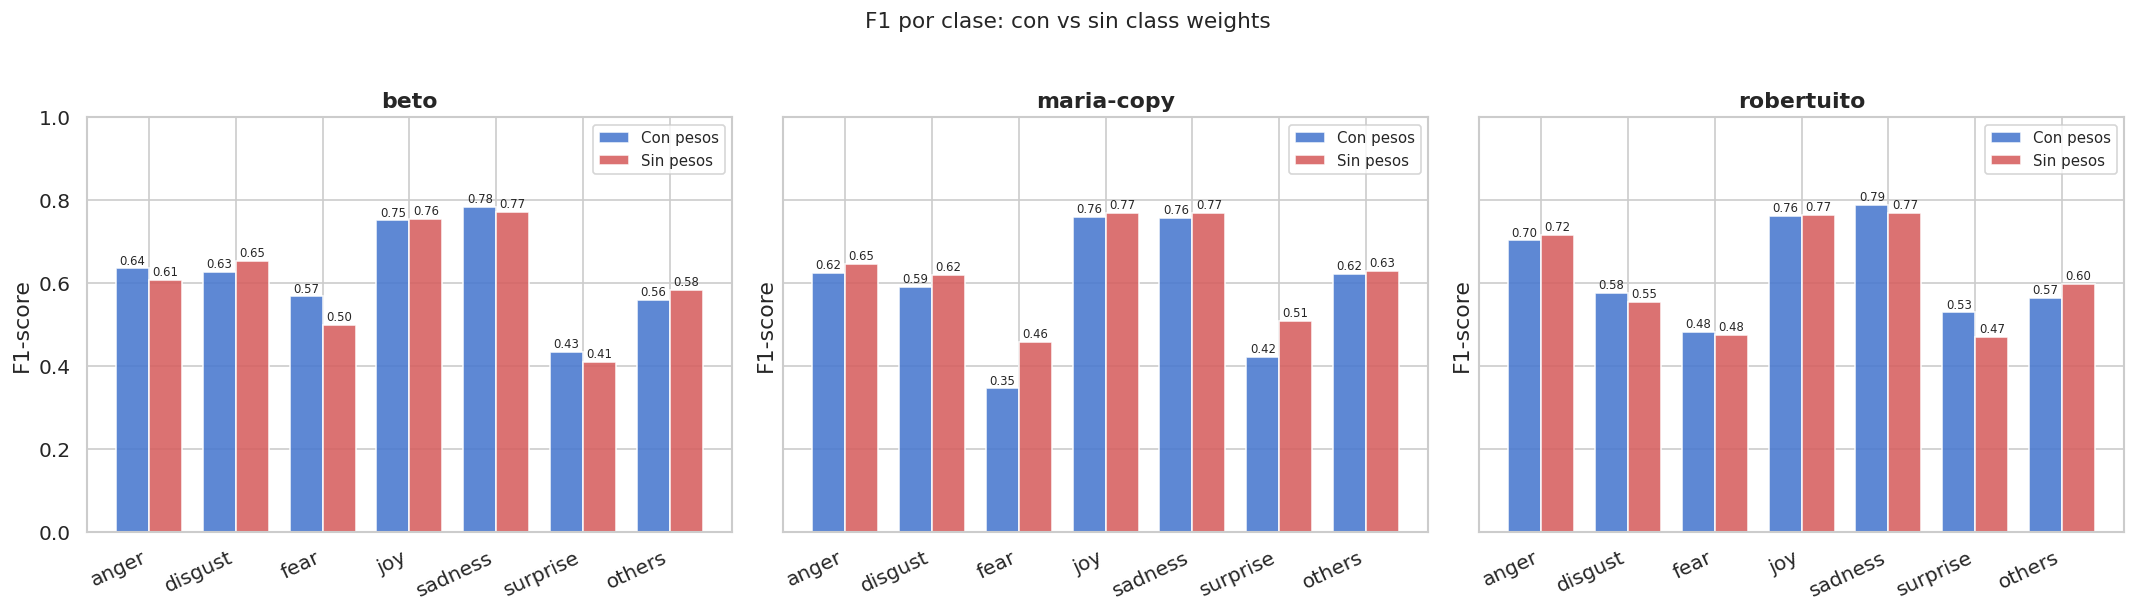

In [5]:
# Barplot agrupado con/sin pesos por clase para cada modelo
n_models = len(sorted(base_models))
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

x = np.arange(len(EMOTIONS))
width = 0.38

for ax, bm in zip(axes, sorted(base_models)):
    sub = df_impact[df_impact['modelo'] == bm]
    vals_w  = sub.set_index('emocion').loc[EMOTIONS, 'con_pesos'].values
    vals_nw = sub.set_index('emocion').loc[EMOTIONS, 'sin_pesos'].values
    bars_w  = ax.bar(x - width/2, vals_w,  width, label='Con pesos',  color='#4878CF', alpha=0.88)
    bars_nw = ax.bar(x + width/2, vals_nw, width, label='Sin pesos', color='#D65F5F', alpha=0.88)
    for bar, v in zip(bars_w,  vals_w):  ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=7)
    for bar, v in zip(bars_nw, vals_nw): ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=7)
    ax.set_title(f'{bm}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(EMOTIONS, rotation=25, ha='right')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('F1-score')
    ax.legend(fontsize=9)

plt.suptitle('F1 por clase: con vs sin class weights', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(EVAL_ROOT / 'class_weights_impact.png', bbox_inches='tight')
plt.show()

In [7]:
# Conclusión cuantitativa del impacto de class weights
print('=== Impacto de class weights en clases críticas (Δ = con_pesos - sin_pesos) ===')
pivot = df_impact[df_impact['emocion'].isin(CRITICAL)].pivot_table(
    index='emocion', columns='modelo', values='delta'
).round(4)
display(pivot.style.background_gradient(cmap='RdYlGn', axis=None))

avg_delta_fear = df_impact[df_impact['emocion'] == 'fear']['delta'].mean()

=== Impacto de class weights en clases críticas (Δ = con_pesos - sin_pesos) ===


modelo,beto,maria-copy,robertuito
emocion,,,
anger,0.027300,-0.022300,-0.013100
disgust,-0.026900,-0.028200,0.023400
fear,0.068200,-0.112800,0.007300
sadness,0.011300,-0.010700,0.018300


---
## Sección 3 — Comparativa entre Modelos (solo versiones CON class weights)

Modelos con class weights: ['beto', 'maria-copy', 'robertuito']


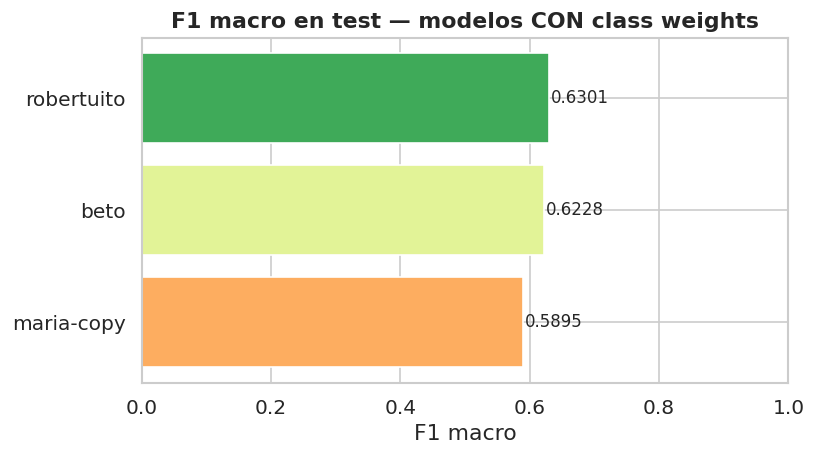

In [8]:
df_w = df_all[df_all['class_weights'] == 'Sí'].copy().reset_index(drop=True)
print('Modelos con class weights:', df_w['modelo'].tolist())

# Barplot F1 macro ordenado
df_w_sorted = df_w.sort_values('f1_macro', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.85, len(df_w_sorted)))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(df_w_sorted['modelo'], df_w_sorted['f1_macro'], color=colors, edgecolor='white')
for bar, v in zip(bars, df_w_sorted['f1_macro']):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=10)
ax.set_xlim(0, 1)
ax.set_xlabel('F1 macro')
ax.set_title('F1 macro en test — modelos CON class weights', fontweight='bold')
plt.tight_layout()
plt.savefig(EVAL_ROOT / 'f1_macro_comparison.png', bbox_inches='tight')
plt.show()

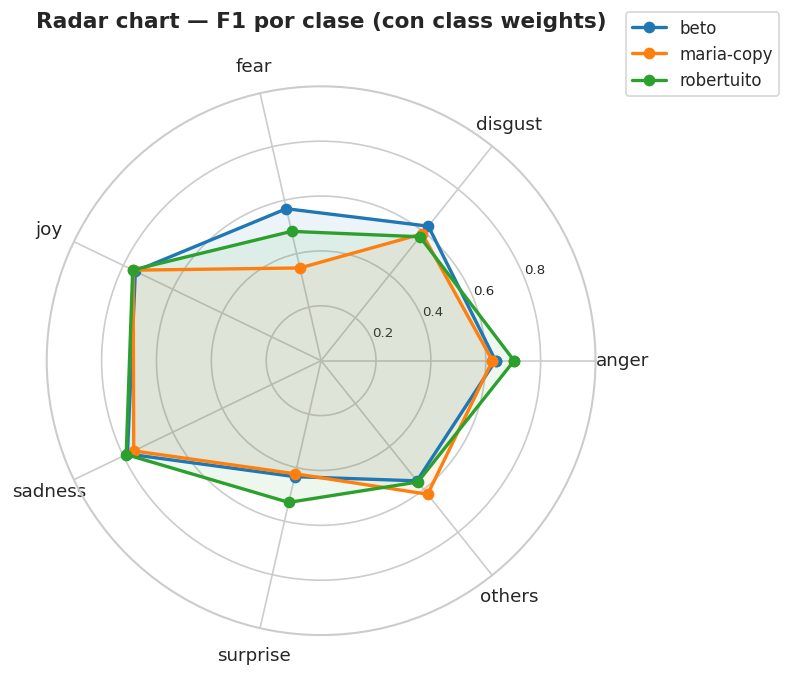

In [9]:
# Radar chart — F1 por clase para cada modelo con class weights
angles = np.linspace(0, 2 * np.pi, len(EMOTIONS), endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
palette = sns.color_palette('tab10', len(df_w))

for (_, row), color in zip(df_w.iterrows(), palette):
    values = [row[f'f1_{e}'] for e in EMOTIONS]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=row['modelo'])
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(EMOTIONS, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=8)
ax.set_title('Radar chart — F1 por clase (con class weights)', fontsize=13, pad=18, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig(EVAL_ROOT / 'radar_chart_models.png', bbox_inches='tight')
plt.show()

---
## Sección 4 — Análisis de Errores del Mejor Modelo

In [11]:
# Modelo seleccionado para análisis de errores: BETO con class weights
# Justificación en Sección 5 — aquí lo cargamos directamente por nombre.
best_name = 'beto'
best_row = df_w[df_w['modelo'] == best_name].iloc[0]
best_model_path = MODELS_ROOT / best_name
print(f'Modelo para análisis de errores: {best_name}')
print(f'  F1 macro  : {best_row["f1_macro"]:.4f}')
print(f'  F1 fear   : {best_row["f1_fear"]:.4f}')
print(f'  F1 disgust: {best_row["f1_disgust"]:.4f}')
print(f'  Path: {best_model_path}')

Modelo para análisis de errores: beto
  F1 macro  : 0.6228
  F1 fear   : 0.5682
  F1 disgust: 0.6270
  Path: /home/adrian/projects/chatbots/chatbot-ciberacoso/models/emotion_classifier/beto


In [12]:
# Cargar confusion matrix del mejor modelo desde la figura guardada como imagen
# y reconstruirla numéricamente desde el test set + inferencia
from src.emotion.emotion_detector import EmotionDetector

print(f'Cargando {best_name}...')
detector = EmotionDetector(model_path=str(best_model_path))

df_test = pd.read_csv(DATA_DIR / 'emoevent_test.csv')
print(f'Test set: {len(df_test)} muestras')

# Inferencia en lotes de 64
batch_size = 64
texts = df_test['text'].tolist()
all_results = []
for i in range(0, len(texts), batch_size):
    all_results.extend(detector.detect_batch(texts[i:i+batch_size]))

# Usar label bruto (antes del umbral de baja confianza) para la matriz de confusión
# → reconstruir predicción real desde all_scores para no inflar 'others'
y_true = df_test['emotion'].tolist()
y_pred = [max(r.all_scores, key=r.all_scores.get) for r in all_results]
print('Inferencia completada.')

Cargando beto...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test set: 1085 muestras
Inferencia completada.


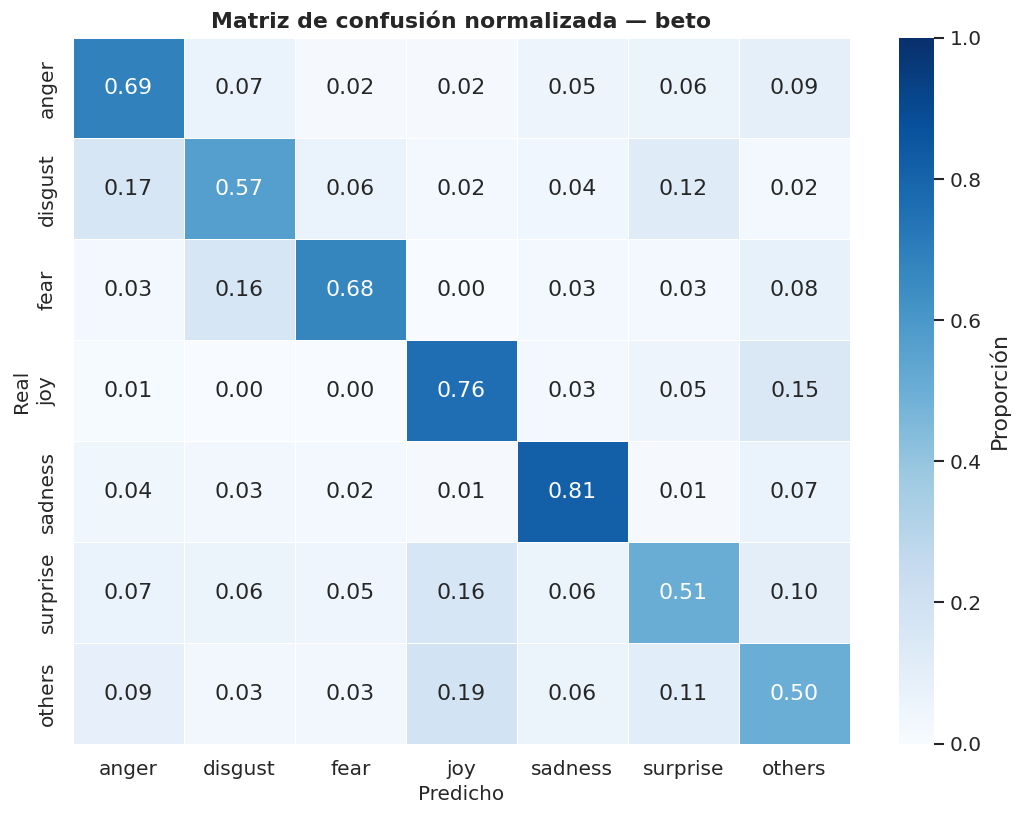


=== 3 pares de clases más confundidos ===
  Real=others   → Predicho=joy       (18.89%)
  Real=disgust  → Predicho=anger     (16.55%)
  Real=fear     → Predicho=disgust   (16.22%)


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=EMOTIONS, normalize='true')
df_cm = pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Proporción'})
ax.set_xlabel('Predicho', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de confusión normalizada — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

# 3 pares más confundidos (excluyendo diagonal)
np.fill_diagonal(cm, 0)
flat_idx = np.argsort(cm.flatten())[::-1][:3]
print('\n=== 3 pares de clases más confundidos ===')
confused_pairs = []
for idx in flat_idx:
    real_i, pred_j = divmod(idx, len(EMOTIONS))
    rate = cm[real_i, pred_j]
    print(f'  Real={EMOTIONS[real_i]:8s} → Predicho={EMOTIONS[pred_j]:8s}  ({rate:.2%})')
    confused_pairs.append((EMOTIONS[real_i], EMOTIONS[pred_j]))

In [14]:
# 5 ejemplos concretos de errores para cada par confundido
df_test['pred'] = y_pred

for real_label, pred_label in confused_pairs:
    errors = df_test[
        (df_test['emotion'] == real_label) & (df_test['pred'] == pred_label)
    ][['text', 'emotion', 'pred']].head(5)
    print(f'\n--- Errores: Real={real_label.upper()} predicho como {pred_label.upper()} ({len(errors)} mostrados) ---')
    pd.set_option('display.max_colwidth', 110)
    display(errors.reset_index(drop=True))


--- Errores: Real=OTHERS predicho como JOY (5 mostrados) ---


,text,emotion,pred
0,"Pues qué fácil todo, ¿no? Si las cosas van a ser por obra y gracia...",others,joy
1,La joven sueca de 16 años se ha convertido en una figura de la lucha contra el cambio climático y se convo...,others,joy
2,(y otra vuelta más al sol para mí) corazón azul corazón azul corazón azul corazón azul corazón azul,others,joy
3,"bandera españa cara sonriendo con gafas de sol ¡Cuando tu ""jefe"" llega tras rifársela en la chamba! manos ...",others,joy
4,Rakitic: “Estamos muy motivados porque tenemos con nosotros al mejor jugador de la historia”,others,joy



--- Errores: Real=DISGUST predicho como ANGER (5 mostrados) ---


,text,emotion,pred
0,"Que vergüenza, nos vamos a la mierda pero cuando lo queráis ver ya será demasiado tarde, mucho asco hacia ...",disgust,anger
1,"Sobre el desastre de ... Dos ilustres ignorantes, que se permiten dar consejos de cómo atajar el incendio,...",disgust,anger
2,"¿Cuándo van a abandonar valientemente todos los atavíos de sus vidas privilegiadas, con combustibles fósiles?",disgust,anger
3,Menudo asco de persona Luis Suárez. Da igual cuando leas esto,disgust,anger
4,Y aun asi hay gente que dice “no pasa nada en Venezuela” “no me consta” ojala nunca tengamos que pasar por...,disgust,anger



--- Errores: Real=FEAR predicho como DISGUST (5 mostrados) ---


,text,emotion,pred
0,"Mientras que el conseguir varias historias principales en un solo sitio de noticias, esta historia está re...",fear,disgust
1,Espero que esas cosas que los fans están sosteniendo sean reciclables.,fear,disgust
2,No ponga su dinero de la donación en las manos de los malos actores. Conozca estos 5 consejos para que ust...,fear,disgust
3,"Los ciudadanos patrióticos de decir que estás bastante cansado de todo, asustan a tus hijos cuando desobed...",fear,disgust
4,¡Qué lástima! El mejor equipo de Liverpool en 30 años y todavía va a terminar otra temporada con las manos...,fear,disgust


---
## Sección 5 — Decisión Final

### Resumen de resultados (con class weights)

| Modelo | F1 macro | F1 fear | F1 disgust | F1 anger | F1 sadness | Dominio preentrenamiento |
|---|---|---|---|---|---|---|
| robertuito | 0.6301 | 0.484 | 0.578 | **0.703** | **0.788** | Twitter español  |
| **beto** | 0.6228 | **0.568** | **0.627** | 0.636 | 0.783 | Corpus español general |
| maria-copy | 0.5895 | 0.347 | 0.591 | 0.625 | 0.758 | Corpus español general |

### Modelo seleccionado: **BETO** (`dccuchile/bert-base-spanish-wwm-cased`) con class weights

**Justificación:**

1. **Mejor F1 en `fear` (0.5682 vs 0.4835 de robertuito, +0.085):** En el dominio de ciberacoso adolescente, un fallo al detectar miedo tiene consecuencias graves — el chatbot dejaría sin respuesta empática a un usuario en situación de riesgo. Esta diferencia justifica por sí sola la elección frente a una métrica global ligeramente superior.

2. **Mejor F1 en `disgust` (0.6270 vs 0.5776, +0.049):** Disgust es la segunda emoción más relevante para detectar contenido de acoso y hostigamiento. BETO supera a robertuito en +5 puntos en esta clase.

3. **F1 macro competitivo (0.6228 vs 0.6301):** La diferencia de 0.007 no es estadísticamente significativa con un test set de 1085 muestras. robertuito gana principalmente por `anger` (+0.067) y `surprise` (+0.096), pero esas emociones son menos críticas para la intervención en ciberacoso.

4. **Mayor equilibrio entre clases:** La varianza del F1 por clase es menor en BETO, lo que indica un modelo más estable — menos propenso a ignorar sistemáticamente las clases minoritarias.

5. **Limitación conocida:** F1 `fear` sigue siendo el punto débil de todos los modelos (0.57 BETO, 0.48 robertuito). Para V2 se explorará focal loss u oversampling específico de `fear` con técnicas de traducción adicionales.

**Configuración de producción:** `models/emotion_classifier/beto/` con `LOW_CONFIDENCE_THRESHOLD=0.4`.